#WEEK 3 EDA for Google Apps Review
irma@its.ac.id/ PBA 2025

In [1]:
# Install necessary packages
!pip install google-play-scraper pandas matplotlib seaborn nltk scikit-learn Sastrawi

from google_play_scraper import Sort, reviews
import pandas as pd

print("Scraping OVO reviews...")
# Scrape the latest 1000 reviews for OVO directly
result, continuation_token = reviews(
    'ovo.id',
    lang='id', # Indonesian language
    country='id', # Indonesia
    sort=Sort.NEWEST,
    count=1000 # Sample size for EDA
)

# Convert to DataFrame
df_ovo = pd.DataFrame(result)

# Display the first few rows
df_ovo[['at', 'userName', 'score', 'content']].head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 12.1 MB/s eta 0:00:00
Scraping OVO reviews...


,at,userName,score,content
0,2026-03-30 14:52:22,Muhammad Zikri,1,aplikasi sampah
1,2026-03-30 14:40:08,Muhammad Rizki,5,acong
2,2026-03-30 14:03:14,Wan Syah,5,oke
3,2026-03-30 14:00:37,Andri Rohi,5,sangat membantu
4,2026-03-30 13:01:06,Dinar Lovestory,1,buruk susah buat upgrade tolong perbaiki ntr g...


# Exploratory Data Analysis (EDA) of JKN Reviews

## 1. Install Necessary Packages
This section ensures that all required Python packages are installed before running the notebook.
```python
!pip install pandas matplotlib seaborn nltk
```

In [2]:
!pip install pandas matplotlib seaborn nltk

## 2. Import Required Libraries
We import essential libraries for data analysis, visualization, and text processing.
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
```

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string

## 3. Download Stopwords
Downloading the Indonesian stopwords from NLTK for text processing.
```python
nltk.download('stopwords')
from nltk.corpus import stopwords
```

In [5]:
!pip install Sastrawi

import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

# Create stemmer and lemmatizer objects
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Force text to string to avoid float (NaN) errors, then lower case
    text = str(text).lower()

    # Punctuation removal
    text = re.sub(r'[^\w\s]', '', text)

    # Stemming
    text = stemmer.stem(text)

    # Lemmatization (requires a part-of-speech tag for optimal results, using 'v' for verb as a default)
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, 'v') for word in words]
    text = ' '.join(lemmatized_words)

    return text

# Apply the cleaning function to the 'content' column
df_ovo['cleaned_review'] = df_ovo['content'].apply(clean_text)

# Fix: Change 'review' to 'content' for the print statement
print(df_ovo[['content', 'cleaned_review']].head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                             content  \
0                                    aplikasi sampah   
1                                              acong   
2                                                oke   
3                                    sangat membantu   
4  buruk susah buat upgrade tolong perbaiki ntr g...   

                                      cleaned_review  
0                                    aplikasi sampah  
1                                              acong  
2                                                oke  
3                                       sangat bantu  
4  buruk susah buat upgrade tolong baik ntr gue k...  


## 5. Data Overview
This section provides basic dataset information, including column names, data types, and the first few records.
```python
# Convert 'at' column to datetime format
df_ovo['at'] = pd.to_datetime(df_ovo['at'])

# Display dataset info and first few rows
df_ovo.info()
df_ovo.head()
```

In [6]:
# Convert 'at' column to datetime format
df_ovo['at'] = pd.to_datetime(df_ovo['at'])

# Display dataset info and first few rows
df_ovo.info()
df_ovo.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              1000 non-null   object        
 1   userName              1000 non-null   object        
 2   userImage             1000 non-null   object        
 3   content               1000 non-null   object        
 4   score                 1000 non-null   int64         
 5   thumbsUpCount         1000 non-null   int64         
 6   reviewCreatedVersion  723 non-null    object        
 7   at                    1000 non-null   datetime64[ns]
 8   replyContent          17 non-null     object        
 9   repliedAt             17 non-null     datetime64[ns]
 10  appVersion            723 non-null    object        
 11  cleaned_review        1000 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 93.9+ KB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_review
0,07c89db7-6228-4b56-8889-49289b4f7265,Muhammad Zikri,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi sampah,1,0,None,2026-03-30 14:52:22,None,NaT,None,aplikasi sampah
1,e6869d69-2d99-49c0-b8fd-2b7f24c5d492,Muhammad Rizki,https://play-lh.googleusercontent.com/a/ACg8oc...,acong,5,0,None,2026-03-30 14:40:08,None,NaT,None,acong
2,d703080b-53ea-4219-9615-0b1024b757a5,Wan Syah,https://play-lh.googleusercontent.com/a/ACg8oc...,oke,5,0,None,2026-03-30 14:03:14,None,NaT,None,oke
3,8bb0855a-a0f0-4026-8c95-fb986fc397cb,Andri Rohi,https://play-lh.googleusercontent.com/a/ACg8oc...,sangat membantu,5,0,3.156.0,2026-03-30 14:00:37,None,NaT,3.156.0,sangat bantu
4,0c176cd6-762b-4652-84c7-b8837bbeabe1,Dinar Lovestory,https://play-lh.googleusercontent.com/a-/ALV-U...,buruk susah buat upgrade tolong perbaiki ntr g...,1,0,3.156.0,2026-03-30 13:01:06,None,NaT,3.156.0,buruk susah buat upgrade tolong baik ntr gue k...


## 6. Missing Values Analysis
Identifies and counts missing values in each column.
```python
missing_values = df_ovo.isnull().sum()
print("Missing Values Summary:")
print(missing_values)
```

In [7]:
missing_values = df_ovo.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
reviewId                  0
userName                  0
userImage                 0
content                   0
score                     0
thumbsUpCount             0
reviewCreatedVersion    277
at                        0
replyContent            983
repliedAt               983
appVersion              277
cleaned_review            0
dtype: int64


## 7. Review Score Distribution
Visualizing the distribution of review scores to understand user sentiments.
```python
plt.figure(figsize=(8,5))
sns.countplot(x=df_ovo['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()
```

/tmp/ipykernel_9582/2019276024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_ovo['score'], palette="viridis")


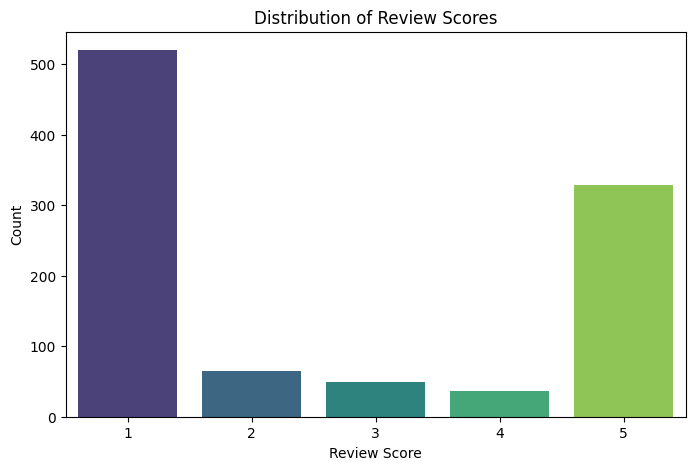

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_ovo['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


## 8. Review Trends Over Time
Analyzing how the number of reviews changes over time to detect patterns.
```python
# Extract review date
df_ovo['review_date'] = df_ovo['at'].dt.date
review_trend = df_ovo.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()
```

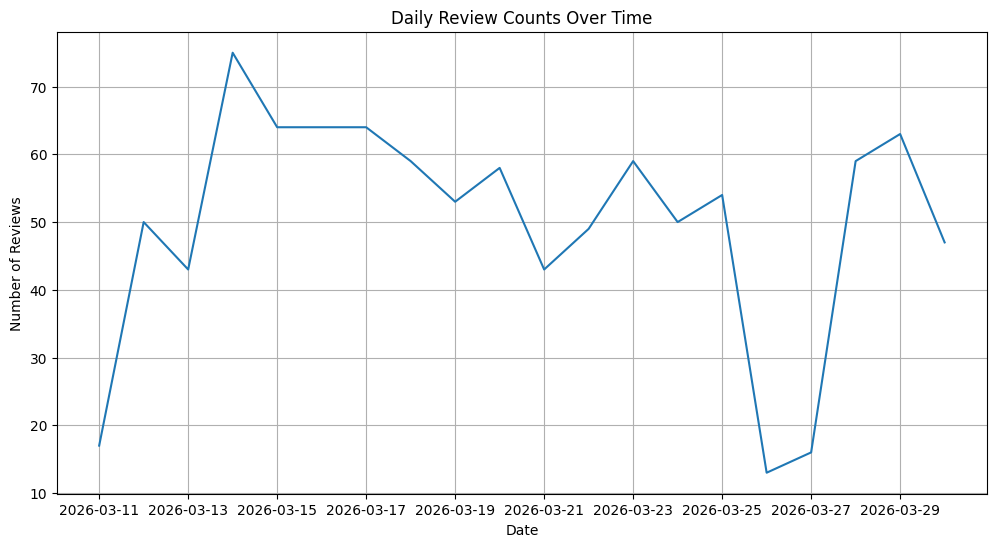

In [9]:
df_ovo['review_date'] = df_ovo['at'].dt.date
review_trend = df_ovo.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

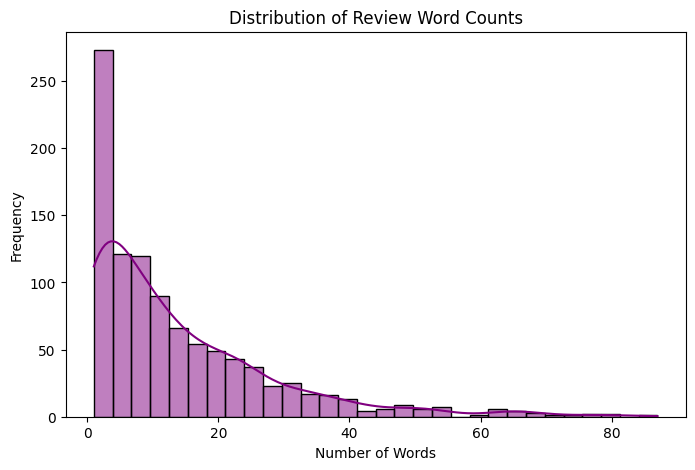

In [12]:
df_ovo['review_length'] = df_ovo['content'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df_ovo['review_length'], bins=30, kde=True, color='purple')
plt.title("Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## 9. Word Frequency Analysis
Analyzing common words in reviews, excluding Indonesian stopwords.
```python
stop_words = set(stopwords.words('indonesian'))

# Combine all review text
all_reviews = " ".join(df_ovo['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)
```

In [16]:
import string
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Make sure the stopwords are downloaded in this session
nltk.download('stopwords')

# Define the Indonesian stopwords
stop_words = set(stopwords.words('indonesian'))
stop_words.update(['nya', 'gak', 'app', 'yg', 'di', 'ke', 'dan', 'gk' ,'ga' ,'ya'])
# Combine all review text from the 'content' column
all_reviews = " ".join(df_ovo['content'].dropna()).lower()

# Remove punctuation
all_reviews = all_reviews.translate(str.maketrans("", "", string.punctuation))

# Tokenization and filtering words
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)

Most Common Words in Reviews:
         Word  Frequency
0         ovo        368
1    aplikasi        194
2       saldo        120
3         apk        119
4       masuk        103
5        udah         94
6         aja         86
7       admin         82
8        akun         82
9    transfer         79
10      bagus         68
11      gagal         65
12       uang         64
13     tolong         60
14  transaksi         56
15     banget         55
16       pake         54
17      biaya         52
18       kena         48
19         tf         47


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# BAG OF WORDS

In [17]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

print("=== Step 1: Siapkan Corpus (Membuang Stopwords) ===")
# Mengambil teks dari 'cleaned_review' dan membuang stop_words yang
# sudah didefinisikan pada tahap EDA sebelumnya.
corpus = []
for text in df_ovo['cleaned_review'].dropna():
    words = text.split()
    # Filter kata yang bukan stopwords
    filtered_sentence = [w for w in words if w not in stop_words]
    # Gabungkan kembali menjadi kalimat
    corpus.append(" ".join(filtered_sentence))

print(f"Total dokumen dalam corpus: {len(corpus)}")
print(f"Contoh corpus ke-1: {corpus[0]}\n")

=== Step 1: Siapkan Corpus (Membuang Stopwords) ===
Total dokumen dalam corpus: 1000
Contoh corpus ke-1: aplikasi sampah



In [18]:
print("=== Step 2: List all unique words ===")
all_words = []
for sentence in corpus:
    for word in sentence.split():
        all_words.append(word)

unique_words = list(set(all_words))
print(f"Total unique words: {len(unique_words)}")
print(f"Contoh 15 unique words: {unique_words[:15]}\n")

=== Step 2: List all unique words ===
Total unique words: 2022
Contoh 15 unique words: ['rekomendit', 'gambang', 'gakk', 'tgl', '1jam', 'dn', 'qris', 'ovosemua', 'pasu', 'telepon', 'pakein', 'jenis', 'telkomsel', 'rekomendasikanmerugikan', 'biar']



In [19]:
print("=== Step 3: Create a dictionary mapping words to a number (Sorted by Frequency) ===")
word_frequencies = Counter(all_words)

# Sorting words by frequency (descending)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

# Creating the dictionary mapping words to numbers
word_to_number = {}
for i, (word, frequency) in enumerate(sorted_words):
    word_to_number[word] = i + 1  # Assign numbers starting from 1

print("Top 10 Word Frequencies:")
for i in range(10):
    print(f" - {sorted_words[i][0]}: {sorted_words[i][1]}")

print("\nTop 10 Word to Number Mapping:")
top_10_mapping = {k: word_to_number[k] for k in list(word_to_number)[:10]}
print(top_10_mapping)
print("\n")

=== Step 3: Create a dictionary mapping words to a number (Sorted by Frequency) ===
Top 10 Word Frequencies:
 - ovo: 369
 - aplikasi: 201
 - saldo: 136
 - apk: 119
 - masuk: 115
 - udah: 94
 - potong: 93
 - aja: 87
 - transfer: 85
 - bantu: 84

Top 10 Word to Number Mapping:
{'ovo': 1, 'aplikasi': 2, 'saldo': 3, 'apk': 4, 'masuk': 5, 'udah': 6, 'potong': 7, 'aja': 8, 'transfer': 9, 'bantu': 10}




In [20]:
print("=== Step 4: Membuat Matriks menggunakan CountVectorizer ===")
# Kita gunakan max_features=1000 agar komputasi tidak terlalu berat untuk 1000+ review
cv = CountVectorizer(max_features=1000)
independentFeatures = cv.fit_transform(corpus).toarray()

print(f"Bentuk Matriks BoW (Baris, Kolom): {independentFeatures.shape}")
print("Contoh Matriks BoW (5 baris pertama):")
print(independentFeatures[:5])

=== Step 4: Membuat Matriks menggunakan CountVectorizer ===
Bentuk Matriks BoW (Baris, Kolom): (1000, 1000)
Contoh Matriks BoW (5 baris pertama):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


# REGEX

In [21]:
import re

# 1. Definisikan pola kata (pattern) untuk sentimen menggunakan Regex
# Gunakan tanda | (OR) untuk memasukkan beberapa kata kunci sekaligus
kata_negatif = r'\b(kecewa|gagal|error|hilang|buruk|penipu|susah|lambat|update|jelek|tolong|rugi|hilang|mahal)\b'
kata_positif = r'\b(bagus|mantap|bantu|membantu|cepat|keren|mudah|terbaik|good|lancar|gampang|puas)\b'

def deteksi_sentimen_regex(text):
    # Ubah teks ke huruf kecil agar cocok dengan pola
    text_lower = str(text).lower()

    # Cari kecocokan menggunakan re.search
    if re.search(kata_negatif, text_lower):
        return 'Negatif'
    elif re.search(kata_positif, text_lower):
        return 'Positif'
    else:
        return 'Netral / Tidak Terdeteksi'

In [22]:
print("=== Proses Deteksi Sentimen menggunakan Regex ===")
# 2. Terapkan fungsi ke kolom teks asli ('content') atau teks bersih
df_ovo['sentimen_regex'] = df_ovo['cleaned_review'].apply(deteksi_sentimen_regex)

=== Proses Deteksi Sentimen menggunakan Regex ===


In [23]:
# 3. Hitung ringkasan jumlah sentimen yang ditemukan
ringkasan_sentimen = df_ovo['sentimen_regex'].value_counts()
print("\nRingkasan Sentimen Hasil Regex:")
print(ringkasan_sentimen)


Ringkasan Sentimen Hasil Regex:
sentimen_regex
Netral / Tidak Terdeteksi    524
Negatif                      295
Positif                      181
Name: count, dtype: int64


/tmp/ipykernel_9582/2320291078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ringkasan_sentimen.index, y=ringkasan_sentimen.values, palette="Set2")


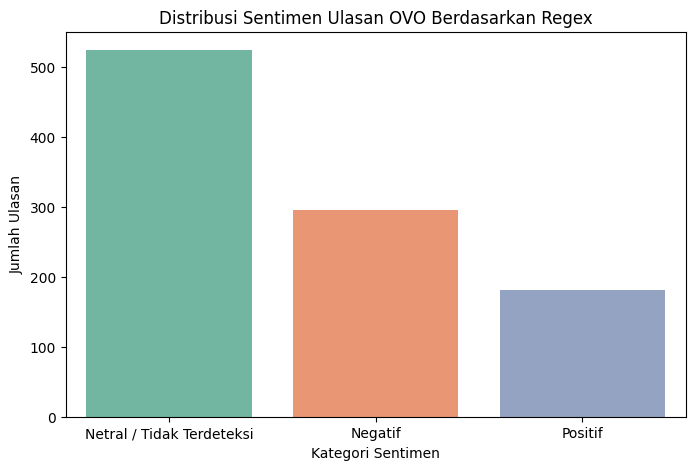

In [24]:
# 4. Visualisasi Distribusi Sentimen
plt.figure(figsize=(8,5))
sns.barplot(x=ringkasan_sentimen.index, y=ringkasan_sentimen.values, palette="Set2")
plt.title("Distribusi Sentimen Ulasan OVO Berdasarkan Regex")
plt.ylabel("Jumlah Ulasan")
plt.xlabel("Kategori Sentimen")
plt.show()

In [26]:
# 5. Tampilkan beberapa contoh hasilnya
print("\n=== Contoh Ulasan yang Terdeteksi Negatif ===")
contoh_negatif = df_ovo[df_ovo['sentimen_regex'] == 'Negatif'][['score', 'cleaned_review']].head(3)
for idx, row in contoh_negatif.iterrows():
    print(f"- {row['score']}: {row['cleaned_review']}")

print("\n=== Contoh Ulasan yang Terdeteksi Positif ===")
contoh_positif = df_ovo[df_ovo['sentimen_regex'] == 'Positif'][['score', 'cleaned_review']].head(3)
for idx, row in contoh_positif.iterrows():
    print(f"- {row['score']}: {row['cleaned_review']}")


=== Contoh Ulasan yang Terdeteksi Negatif ===
- 1: buruk susah buat upgrade tolong baik ntr gue kasih bintang 5 kalau udh baik
- 1: rasa kecewa pihak ovo tidak mau kembali uanga saya saya tidak rasa transaksi nila 300rb
- 1: tiap mau tf selalu ga bisa selalu aja gagal muat konten ini maksud gimana sih jadi mls pke ovo lama lama

=== Contoh Ulasan yang Terdeteksi Positif ===
- 5: sangat bantu
- 5: lumayan sangat bantu bagi gw
- 5: respon cepat
